# Analyse exploratoire

Notre objectif est d'analysé les données du pilote leclerc pendant la course de Monza en 2022.

In [1]:
pip install fastf1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00


In [2]:
# Chargement de la bibliothèque fastf1 ainsi que le cache
import fastf1
from pathlib import Path

CACHE_DIR = Path("/content/fastf1_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_DIR))

In [3]:
import logging
import warnings

warnings.filterwarnings("ignore")

for logger_name in [
    "fastf1",
    "fastf1.fastf1",
    "fastf1.fastf1.req",
    "fastf1.api"
]:
    logging.getLogger(logger_name).setLevel(logging.ERROR)

# Structure des données

Dans cette étape nous allons sélectionner les données en rapport avec la pilote puis faire un étude afin de comprendre la structure des données

In [4]:
# Chargement de la course de Monza en 2022
session = fastf1.get_session(2022, 'Monza', 'R')
session.load()
laps = session.laps

In [5]:
laps_lec = laps.pick_driver('LEC')
laps_lec.info()

<class 'fastf1.core.Laps'>
Index: 53 entries, 190 to 242
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Time                53 non-null     timedelta64[ns]
 1   Driver              53 non-null     object         
 2   DriverNumber        53 non-null     object         
 3   LapTime             53 non-null     timedelta64[ns]
 4   LapNumber           53 non-null     float64        
 5   Stint               53 non-null     float64        
 6   PitOutTime          3 non-null      timedelta64[ns]
 7   PitInTime           3 non-null      timedelta64[ns]
 8   Sector1Time         52 non-null     timedelta64[ns]
 9   Sector2Time         53 non-null     timedelta64[ns]
 10  Sector3Time         53 non-null     timedelta64[ns]
 11  Sector1SessionTime  52 non-null     timedelta64[ns]
 12  Sector2SessionTime  53 non-null     timedelta64[ns]
 13  Sector3SessionTime  53 non-null     timedelta64[ns

La table contenant les information du pilote Leclerc contient 31 colonnes avec des types tels que :
bool, datetime64[ns], float64, object, timedelta64[ns]

In [6]:
laps_lec.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
190,0 days 01:03:56.469000,LEC,16,0 days 00:01:28.085000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:29.537000,...,True,Ferrari,0 days 01:02:28.137000,2022-09-11 13:03:28.378,1,1.0,False,,False,False
191,0 days 01:05:23.004000,LEC,16,0 days 00:01:26.535000,2.0,1.0,NaT,NaT,0 days 00:00:28.687000,0 days 00:00:29.260000,...,True,Ferrari,0 days 01:03:56.469000,2022-09-11 13:04:56.710,1,1.0,False,,False,True
192,0 days 01:06:49.356000,LEC,16,0 days 00:01:26.352000,3.0,1.0,NaT,NaT,0 days 00:00:28.359000,0 days 00:00:29.434000,...,True,Ferrari,0 days 01:05:23.004000,2022-09-11 13:06:23.245,1,1.0,False,,False,True
193,0 days 01:08:15.158000,LEC,16,0 days 00:01:25.802000,4.0,1.0,NaT,NaT,0 days 00:00:28.202000,0 days 00:00:29.144000,...,True,Ferrari,0 days 01:06:49.356000,2022-09-11 13:07:49.597,1,1.0,False,,False,True
194,0 days 01:09:41.060000,LEC,16,0 days 00:01:25.902000,5.0,1.0,NaT,NaT,0 days 00:00:28.140000,0 days 00:00:29.351000,...,True,Ferrari,0 days 01:08:15.158000,2022-09-11 13:09:15.399,1,1.0,False,,False,True


In [7]:
laps_lec.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')

In [8]:
laps_lec.shape

(53, 31)

Il y 53 lignes et 31 colennes dans ce dataset en d'autre terme nous avons 53 tours dans cette courses et 31 informations par tour

In [9]:
laps_lec.isna().sum()

,0
Time,0
Driver,0
DriverNumber,0
LapTime,0
LapNumber,0
Stint,0
PitOutTime,50
PitInTime,50
Sector1Time,1
Sector2Time,0


Les colonnes Sector1SectionTime1 , SpeedFL, Sector1Time, PitinTime, PitOutTime possède des varaiable null

In [10]:
fastest_laps_lec = laps_lec.pick_fastest()
fastest_laps_lec

,227
Time,0 days 01:57:50.428000
Driver,LEC
DriverNumber,16
LapTime,0 days 00:01:24.336000
LapNumber,38.0
Stint,3.0
PitOutTime,NaT
PitInTime,NaT
Sector1Time,0 days 00:00:27.695000
Sector2Time,0 days 00:00:28.749000


In [11]:
laps_lec_telemetry = fastest_laps_lec.get_telemetry()
laps_lec_telemetry

,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2022-09-11 13:57:26.333,0 days 01:56:26.092000,,1214.801944,0 days 00:00:00,11130.029983,311.945000,8,100.0,False,0,interpolation,0.213615,0.000037,OnTrack,-1384.686225,-802.987846,1871.021829
3,2022-09-11 13:57:26.344,0 days 01:56:26.103000,,1214.801944,0 days 00:00:00.011000,11133.000000,312.000000,8,100.0,False,0,car,1.169444,0.000202,OnTrack,-1383.894595,-793.616807,1871.019538
4,2022-09-11 13:57:26.397,0 days 01:56:26.156000,,1214.801944,0 days 00:00:00.064000,11152.543726,312.331250,8,100.0,False,0,pos,5.776615,0.001000,OnTrack,-1380.000000,-749.000000,1871.000000
5,2022-09-11 13:57:26.497,0 days 01:56:26.256000,,1214.801944,0 days 00:00:00.164000,11189.418726,312.956250,8,100.0,False,0,pos,14.472213,0.002504,OnTrack,-1372.000000,-662.000000,1871.000000
6,2022-09-11 13:57:26.504,0 days 01:56:26.263000,1,1214.801944,0 days 00:00:00.171000,11192.000000,313.000000,8,100.0,False,0,car,15.080556,0.002609,OnTrack,-1371.355851,-654.827405,1871.015396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,2022-09-11 13:58:50.417,0 days 01:57:50.176000,1,1194.808890,0 days 00:01:24.084000,11063.709970,308.929999,8,100.0,False,0,pos,5723.174599,0.990287,OnTrack,-1403.000000,-1043.000000,1870.000000
658,2022-09-11 13:58:50.424,0 days 01:57:50.183000,1,1194.678611,0 days 00:01:24.091000,11067.000000,309.000000,8,100.0,False,0,car,5723.777500,0.990391,OnTrack,-1402.502211,-1036.572843,1870.040426
659,2022-09-11 13:58:50.577,0 days 01:57:50.336000,1,1191.831112,0 days 00:01:24.244000,11088.419991,310.529999,8,100.0,False,0,pos,5736.987721,0.992677,OnTrack,-1391.000000,-888.000000,1871.000000
660,2022-09-11 13:58:50.624,0 days 01:57:50.383000,1,1190.956389,0 days 00:01:24.291000,11095.000000,311.000000,8,100.0,False,0,car,5741.055278,0.993381,OnTrack,-1387.590966,-844.439344,1871.160157


In [12]:
laps_lec_telemetry.columns

Index(['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time',
       'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z'],
      dtype='object')

In [13]:
laps_lec_telemetry.info()

<class 'fastf1.core.Telemetry'>
Index: 660 entries, 2 to 661
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   Date                   660 non-null    datetime64[ns] 
 1   SessionTime            660 non-null    timedelta64[ns]
 2   DriverAhead            660 non-null    object         
 3   DistanceToDriverAhead  660 non-null    float64        
 4   Time                   660 non-null    timedelta64[ns]
 5   RPM                    660 non-null    float64        
 6   Speed                  660 non-null    float64        
 7   nGear                  660 non-null    int64          
 8   Throttle               660 non-null    float64        
 9   Brake                  660 non-null    bool           
 10  DRS                    660 non-null    int64          
 11  Source                 660 non-null    object         
 12  Distance               660 non-null    float64        
 13  R

In [14]:
laps_lec_telemetry.shape

(660, 18)

In [15]:
laps_lec_telemetry_reduced = laps_lec_telemetry[
    [
        "Time",
        "SessionTime",
        "Distance",
        "Speed",
        "RPM",
        "nGear",
        "Throttle",
        "Brake",
        "DRS",
        "X",
        "Y",
        "Z"
    ]
]
laps_lec_telemetry_reduced

,Time,SessionTime,Distance,Speed,RPM,nGear,Throttle,Brake,DRS,X,Y,Z
2,0 days 00:00:00,0 days 01:56:26.092000,0.213615,311.945000,11130.029983,8,100.0,False,0,-1384.686225,-802.987846,1871.021829
3,0 days 00:00:00.011000,0 days 01:56:26.103000,1.169444,312.000000,11133.000000,8,100.0,False,0,-1383.894595,-793.616807,1871.019538
4,0 days 00:00:00.064000,0 days 01:56:26.156000,5.776615,312.331250,11152.543726,8,100.0,False,0,-1380.000000,-749.000000,1871.000000
5,0 days 00:00:00.164000,0 days 01:56:26.256000,14.472213,312.956250,11189.418726,8,100.0,False,0,-1372.000000,-662.000000,1871.000000
6,0 days 00:00:00.171000,0 days 01:56:26.263000,15.080556,313.000000,11192.000000,8,100.0,False,0,-1371.355851,-654.827405,1871.015396
...,...,...,...,...,...,...,...,...,...,...,...,...
657,0 days 00:01:24.084000,0 days 01:57:50.176000,5723.174599,308.929999,11063.709970,8,100.0,False,0,-1403.000000,-1043.000000,1870.000000
658,0 days 00:01:24.091000,0 days 01:57:50.183000,5723.777500,309.000000,11067.000000,8,100.0,False,0,-1402.502211,-1036.572843,1870.040426
659,0 days 00:01:24.244000,0 days 01:57:50.336000,5736.987721,310.529999,11088.419991,8,100.0,False,0,-1391.000000,-888.000000,1871.000000
660,0 days 00:01:24.291000,0 days 01:57:50.383000,5741.055278,311.000000,11095.000000,8,100.0,False,0,-1387.590966,-844.439344,1871.160157


# Détection des erreurs

In [16]:
laps_lec_telemetry_reduced.isna().sum()

,0
Time,0
SessionTime,0
Distance,0
Speed,0
RPM,0
nGear,0
Throttle,0
Brake,0
DRS,0
X,0


In [17]:
clean_telemetry = laps_lec_telemetry_reduced.sort_values("Distance")
clean_telemetry = clean_telemetry.reset_index(drop=True)
clean_telemetry

,Time,SessionTime,Distance,Speed,RPM,nGear,Throttle,Brake,DRS,X,Y,Z
0,0 days 00:00:00,0 days 01:56:26.092000,0.213615,311.945000,11130.029983,8,100.0,False,0,-1384.686225,-802.987846,1871.021829
1,0 days 00:00:00.011000,0 days 01:56:26.103000,1.169444,312.000000,11133.000000,8,100.0,False,0,-1383.894595,-793.616807,1871.019538
2,0 days 00:00:00.064000,0 days 01:56:26.156000,5.776615,312.331250,11152.543726,8,100.0,False,0,-1380.000000,-749.000000,1871.000000
3,0 days 00:00:00.164000,0 days 01:56:26.256000,14.472213,312.956250,11189.418726,8,100.0,False,0,-1372.000000,-662.000000,1871.000000
4,0 days 00:00:00.171000,0 days 01:56:26.263000,15.080556,313.000000,11192.000000,8,100.0,False,0,-1371.355851,-654.827405,1871.015396
...,...,...,...,...,...,...,...,...,...,...,...,...
655,0 days 00:01:24.084000,0 days 01:57:50.176000,5723.174599,308.929999,11063.709970,8,100.0,False,0,-1403.000000,-1043.000000,1870.000000
656,0 days 00:01:24.091000,0 days 01:57:50.183000,5723.777500,309.000000,11067.000000,8,100.0,False,0,-1402.502211,-1036.572843,1870.040426
657,0 days 00:01:24.244000,0 days 01:57:50.336000,5736.987721,310.529999,11088.419991,8,100.0,False,0,-1391.000000,-888.000000,1871.000000
658,0 days 00:01:24.291000,0 days 01:57:50.383000,5741.055278,311.000000,11095.000000,8,100.0,False,0,-1387.590966,-844.439344,1871.160157


# Reperer les tendances

In [18]:
clean_telemetry.head()

,Time,SessionTime,Distance,Speed,RPM,nGear,Throttle,Brake,DRS,X,Y,Z
0,0 days 00:00:00,0 days 01:56:26.092000,0.213615,311.94500,11130.029983,8,100.0,False,0,-1384.686225,-802.987846,1871.021829
1,0 days 00:00:00.011000,0 days 01:56:26.103000,1.169444,312.00000,11133.000000,8,100.0,False,0,-1383.894595,-793.616807,1871.019538
2,0 days 00:00:00.064000,0 days 01:56:26.156000,5.776615,312.33125,11152.543726,8,100.0,False,0,-1380.000000,-749.000000,1871.000000
3,0 days 00:00:00.164000,0 days 01:56:26.256000,14.472213,312.95625,11189.418726,8,100.0,False,0,-1372.000000,-662.000000,1871.000000
4,0 days 00:00:00.171000,0 days 01:56:26.263000,15.080556,313.00000,11192.000000,8,100.0,False,0,-1371.355851,-654.827405,1871.015396


In [19]:
clean_telemetry.info()

<class 'fastf1.core.Telemetry'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype          
---  ------       --------------  -----          
 0   Time         660 non-null    timedelta64[ns]
 1   SessionTime  660 non-null    timedelta64[ns]
 2   Distance     660 non-null    float64        
 3   Speed        660 non-null    float64        
 4   RPM          660 non-null    float64        
 5   nGear        660 non-null    int64          
 6   Throttle     660 non-null    float64        
 7   Brake        660 non-null    bool           
 8   DRS          660 non-null    int64          
 9   X            660 non-null    float64        
 10  Y            660 non-null    float64        
 11  Z            660 non-null    float64        
dtypes: bool(1), float64(7), int64(2), timedelta64[ns](2)
memory usage: 57.5 KB


In [20]:
clean_telemetry.describe()

,Time,SessionTime,Distance,Speed,RPM,nGear,Throttle,DRS,X,Y,Z
count,660,660,660.000000,660.000000,660.000000,660.000000,660.000000,660.0,660.000000,660.000000,660.000000
mean,0 days 00:00:41.849063636,0 days 01:57:07.941063636,2771.552596,243.581810,10649.150073,6.281818,80.040750,0.0,3050.869123,7073.758355,1908.978044
std,0 days 00:00:24.701898857,0 days 00:00:24.701898857,1636.036629,69.662662,1027.432822,1.853341,35.004677,0.0,4151.352747,6793.576501,36.052021
min,0 days 00:00:00,0 days 01:56:26.092000,0.213615,70.000000,6328.000000,2.000000,0.000000,0.0,-1499.000000,-5801.000000,1842.850058
25%,0 days 00:00:20.489250,0 days 01:56:46.581250,1288.403758,196.300000,10570.106766,5.000000,78.393229,0.0,-419.804278,1468.557611,1879.144739
50%,0 days 00:00:41.011000,0 days 01:57:07.103000,2595.100278,256.893754,10945.565262,7.000000,100.000000,0.0,1458.463029,8353.310480,1916.862791
75%,0 days 00:01:03.589000,0 days 01:57:29.681000,4154.777718,307.279948,11171.000000,8.000000,100.000000,0.0,6700.016055,13376.890778,1936.015472
max,0 days 00:01:24.336000,0 days 01:57:50.428000,5744.953167,325.000000,11911.000000,8.000000,100.000000,0.0,11067.000000,15881.000000,1967.294699


In [21]:
max_speed = clean_telemetry["Speed"].max()
avg_speed = clean_telemetry["Speed"].mean()
avg_throttle = clean_telemetry["Throttle"].mean()
max_rpm = clean_telemetry["RPM"].max()

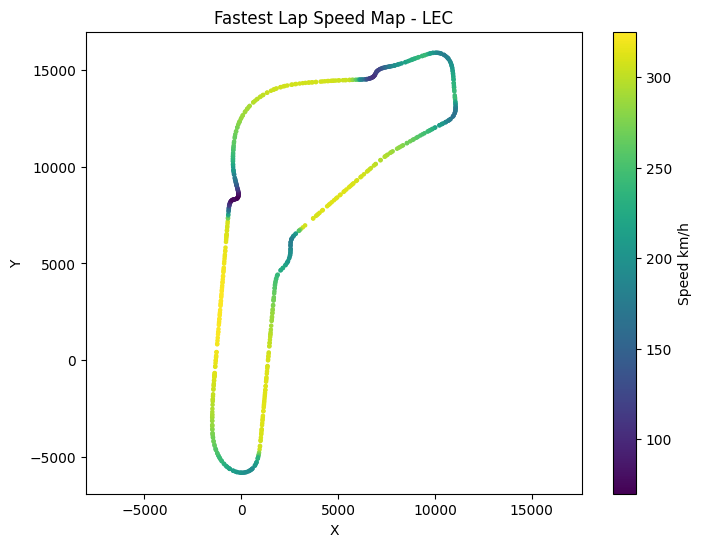

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    clean_telemetry["X"],
    clean_telemetry["Y"],
    c=clean_telemetry["Speed"],
    s=5
)

plt.colorbar(scatter, label="Speed km/h")
plt.title("Fastest Lap Speed Map - LEC")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.show()

Text(0, 0.5, 'Speed (km/h)')

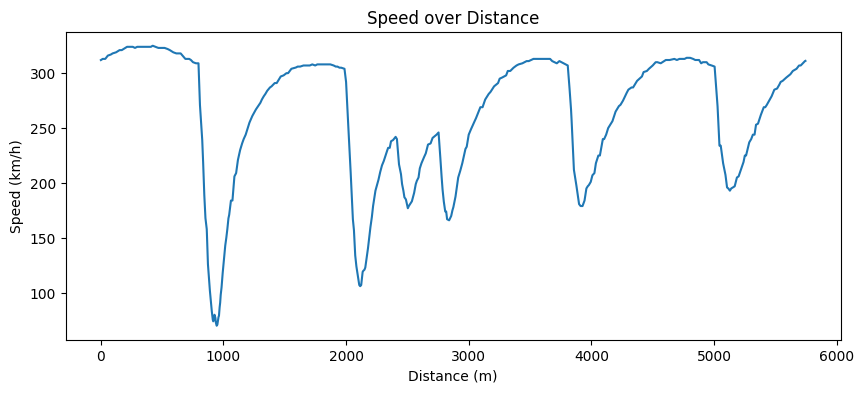

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(clean_telemetry["Distance"], clean_telemetry["Speed"])
plt.title("Speed over Distance")
plt.xlabel("Distance (m)")
plt.ylabel("Speed (km/h)")

Text(0, 0.5, 'Throttle (%)')

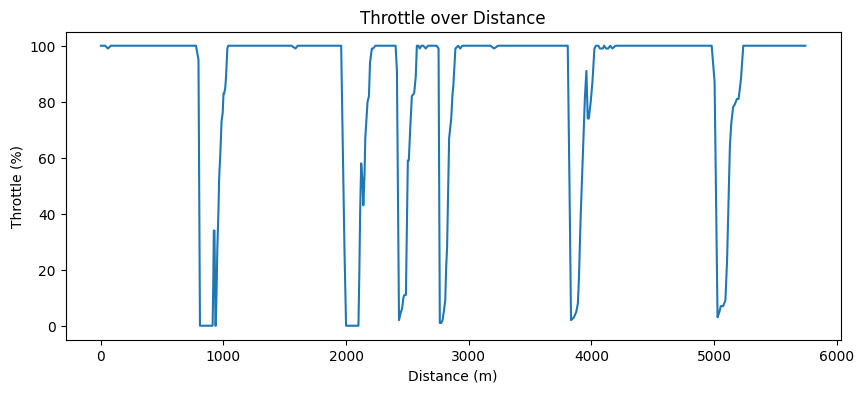

In [24]:
plt.figure(figsize=(10, 4))
plt.plot(clean_telemetry["Distance"], clean_telemetry["Throttle"])
plt.title("Throttle over Distance")
plt.xlabel("Distance (m)")
plt.ylabel("Throttle (%)")

Text(0, 0.5, 'Brake')

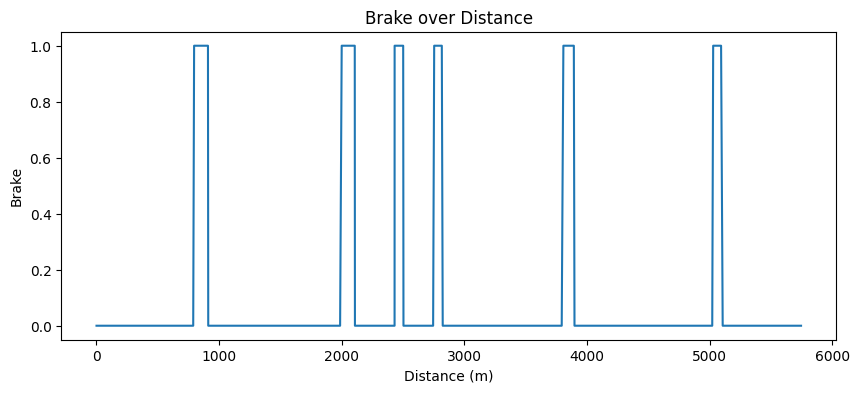

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(clean_telemetry["Distance"], clean_telemetry["Brake"])
plt.title("Brake over Distance")
plt.xlabel("Distance (m)")
plt.ylabel("Brake")

In [26]:
clean_telemetry.to_csv("lec_telemetry.csv", index=False)